# K-pop Album Sales Prediction: perform exploratory data analysis (EDA)

## 0. Загрузка данных. Первый просмотр

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/lyrics_SEX_11k.csv')

In [17]:
df.head()

,Unnamed: 0,track_id,artist_name,track_name,album_name,album_release_date,duration_ms,explicit,track_number,disc_number,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,energy_danceability_score,gender_type,is_group,lyrics
0,0,1lbn4BraBUHY7jFf3oe1WY,&TEAM,Running with the pack - &TEAM ver.,First Howling : NOW,2023-11-15,185640,0,18,1,...,-4.416,0.2950,0.15800,0.000000,0.1130,0.496,0.506522,0.0,1.0,I am not alone anymore\nRunning with the pack\...
1,1,6EGXuyLBotCYrtvOtDOWrM,&TEAM,Yukiakari,Yukiakari,2024-12-16,193704,0,1,1,...,-4.995,0.0572,0.00667,0.000000,0.2120,0.481,0.382776,0.0,1.0,"Oh, oh, woah\nOh-oh, oh-oh, oh-oh, oh\nOh-oh, ..."
2,3,2BQEQhfUtEJXtbxaOv96Xg,&TEAM,Koegawari,Koegawari,2024-07-18,198486,0,1,1,...,-4.057,0.0582,0.01600,0.000003,0.2310,0.798,0.674016,0.0,1.0,Don't think I can't feel anymore\nFeel anymore...
3,4,1zTLMgEeNgwAeUidaBHo4q,&TEAM,Wonderful World,Magic Hour / Wonderful World,2025-01-08,150057,0,2,1,...,-3.714,0.0763,0.08630,0.000000,0.0592,0.962,0.754202,0.0,1.0,"君が僕に出会うまでの道中\n小さな""奇跡""が繋げてる\n映画みたいじゃない\nいっそう輝くr..."
4,5,3dpkuoTzWMdkeV9PguE0Vl,&TEAM,Deer Hunter - Korean ver.,雪明かり (Yukiakari),2024-12-17,186673,0,21,1,...,-5.551,0.2260,0.46500,0.000008,0.0676,0.791,0.697996,0.0,1.0,My primal instincts are awake\nWon't fade away...


Целевая переменная — **track_popularity**

In [18]:
display(df.describe(include="object"))

,track_id,artist_name,track_name,album_name,album_release_date,lyrics
count,11777,11777,11777,11777,11777,11777
unique,11777,447,10537,5657,3053,10850
top,7E1DOxbisaElIe00uZpYqo,IZ*ONE,Hello,ONE,2024-04-01,A\n* About Time by Cosmic Boy ft. Thama & GIRI...
freq,1,50,16,25,28,54


Видим, что есть одинаковые тексты — это версии песен, ремиксы и тд. Удалим те, которые встречаются больше 5 раз

In [19]:
# находим тексты, которые встречаются более 5 раз
lyrics_counts = df["lyrics"].value_counts()

duplicate_lyrics = lyrics_counts[lyrics_counts > 5].index

# удаляем
df = df[~df["lyrics"].isin(duplicate_lyrics)].reset_index(drop=True)

In [12]:
display(df.describe(include="object"))

,track_id,artist_name,track_name,album_name,album_release_date,lyrics
count,11407,11407,11407,11407,11407,11407
unique,11407,447,10188,5531,3017,10819
top,7E1DOxbisaElIe00uZpYqo,IVE,Hello,ONE,2024-04-01,Rich or poverty\n어디 어떻게 사는진 아무 신경 쓸 겨를 없이\n어디든...
freq,1,50,16,24,28,5


Смотрим на итоговый размер датасета

In [13]:
print(f"Размер датасета: {df.shape}")
print(f"Количество признаков: {df.shape[1]}")

Размер датасета: (11407, 31)
Количество признаков: 31


In [14]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11407 entries, 0 to 11406
Data columns (total 31 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  11407 non-null  int64  
 1   track_id                    11407 non-null  object 
 2   artist_name                 11407 non-null  object 
 3   track_name                  11407 non-null  object 
 4   album_name                  11407 non-null  object 
 5   album_release_date          11407 non-null  object 
 6   duration_ms                 11407 non-null  int64  
 7   explicit                    11407 non-null  int64  
 8   track_number                11407 non-null  int64  
 9   disc_number                 11407 non-null  int64  
 10  track_popularity            11407 non-null  int64  
 11  album_popularity            11407 non-null  int64  
 12  track_vs_album_popularity   11407 non-null  float64
 13  artist_popularity           114

None

В наших данных нет пропусков. Большую часть переменных представляют числовые данные

In [15]:
display(df.describe())

,Unnamed: 0,duration_ms,explicit,track_number,disc_number,track_popularity,album_popularity,track_vs_album_popularity,artist_popularity,artist_followers,...,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,energy_danceability_score,gender_type,is_group
count,11407.000000,1.140700e+04,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,1.140700e+04,...,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000,11407.000000
mean,15514.545805,2.059369e+05,0.043920,3.918296,1.015078,20.921802,23.469010,1.062707,41.746647,1.548169e+06,...,0.707535,-5.377027,0.089813,0.261021,0.039462,0.198175,0.530043,0.454990,0.358464,0.585868
std,9752.666273,5.892486e+04,0.204927,3.922020,0.168907,15.907926,16.343297,0.523680,18.731203,6.065918e+06,...,0.198329,3.424947,0.100729,0.268619,0.169303,0.156877,0.232111,0.171881,0.523617,0.492593
min,0.000000,1.875200e+04,0.000000,1.000000,1.000000,1.000000,1.000000,0.037037,0.000000,0.000000e+00,...,0.000507,-45.864000,0.000000,0.000004,0.000000,0.013100,0.000000,0.000000,0.000000,0.000000
25%,5728.500000,1.846625e+05,0.000000,1.000000,1.000000,8.000000,10.000000,0.811679,30.000000,5.678500e+04,...,0.588000,-6.369000,0.037000,0.044100,0.000000,0.097800,0.346000,0.339727,0.000000,0.000000
50%,15677.000000,2.035330e+05,0.000000,3.000000,1.000000,18.000000,21.000000,1.000000,43.000000,2.213120e+05,...,0.755000,-4.604000,0.054700,0.153000,0.000000,0.137000,0.542000,0.485352,0.000000,1.000000
75%,24221.500000,2.265330e+05,0.000000,5.000000,1.000000,31.000000,34.000000,1.190476,54.000000,8.622920e+05,...,0.864000,-3.373000,0.097450,0.410000,0.000007,0.267500,0.714000,0.588681,1.000000,1.000000
max,31819.000000,3.630303e+06,1.000000,73.000000,6.000000,85.000000,87.000000,6.815000,89.000000,7.842046e+07,...,1.000000,0.591000,0.964000,0.994000,0.999000,0.985000,0.980000,0.869648,3.000000,1.000000


В итоговом датасете содержится 11 407 наблюдений, при этом пропуски отсутствуют. Средняя популярность трека составляет 20.9 балла, однако медиана равна 18, что указывает на преобладание менее популярных композиций и наличие небольшого числа очень популярных треков. Также заметен большой разброс по таким признакам, как количество подписчиков исполнителя (artist_followers) и длительность треков (duration_ms), что говорит о том, что в датасет попали как практически безызвестные авторы, так и очень известные исполнители типа BTS. В целом смещение в сторону непопулярных треков отражает естественное распределение популярных и непопулярных треков в индустрии — немногие треки становятся действительно популярными.

Тем не менее, стоит учитывать это при обучении.
Для задачи классификации есть смысл делить треки следующим образом:


*   До 20 — непопулярные треки
*   От 30 до 85 — популярные треки



## Типы признаков, состав датасета

**Числовые**

музыкальные показатели:

* tempo
* danceability
* energy
* loudness
* speechiness
* acousticness
* instrumentalness
* liveness
* valence

остальные метаданные:

* duration_ms
* track_popularity (target)
* album_popularity
* artist_popularity
* artist_followers
* track_vs_album_popularity
* album_vs_artist_popularity
* energy_danceability_score

**Категориальные**

* explicit
* key
* mode
* gender_type
* is_group

**Текстовые**

* lyrics
* track_name
* album_name
* artist_name

# 1. Распределение данных: анализ выбросов

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

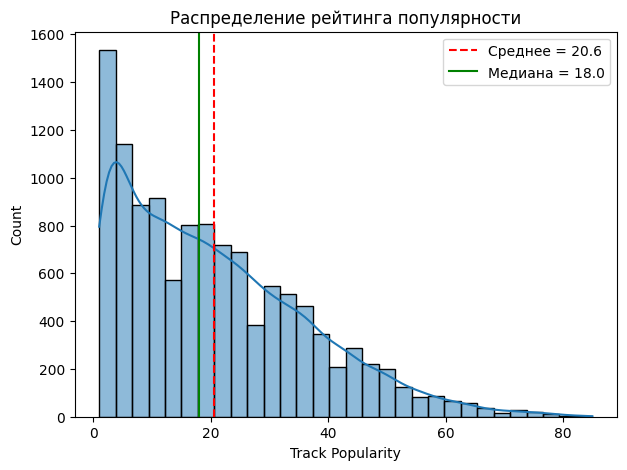

In [18]:
mean = df["track_popularity"].mean()
median = df["track_popularity"].median()

plt.figure(figsize=(7, 5))

sns.histplot(df["track_popularity"], bins=30, kde=True)

plt.axvline(mean, color="red", linestyle="--", label=f"Среднее = {mean:.1f}")
plt.axvline(median, color="green", linestyle="-", label=f"Медиана = {median:.1f}")

plt.title("Распределение рейтинга популярности")
plt.xlabel("Track Popularity")
plt.ylabel("Count")
plt.legend()

plt.show()

В данных действительно гораздо больше непопулярных тректов и экстремально мало очень популярных треков, что скорее соответствует естественной ситуации в рассматриваемой индустрии.

In [22]:
# посчитаем длину текстов в словах

df["lyrics_length_words"] = df["lyrics"].str.split().str.len()

df[["lyrics", "lyrics_length_words"]].head()

,lyrics,lyrics_length_words
0,I am not alone anymore\nRunning with the pack\...,218
1,"Oh, oh, woah\nOh-oh, oh-oh, oh-oh, oh\nOh-oh, ...",122
2,Don't think I can't feel anymore\nFeel anymore...,200
3,"君が僕に出会うまでの道中\n小さな""奇跡""が繋げてる\n映画みたいじゃない\nいっそう輝くr...",202
4,My primal instincts are awake\nWon't fade away...,299


In [24]:
df["lyrics_length_words"].describe()

,lyrics_length_words
count,11777.000000
mean,1706.145793
std,8280.089845
min,1.000000
25%,193.000000
50%,278.000000
75%,401.000000
max,149171.000000


In [32]:
# переводим длительность аудио в минуты

df["duration_min"] = df["duration_ms"] / 60000

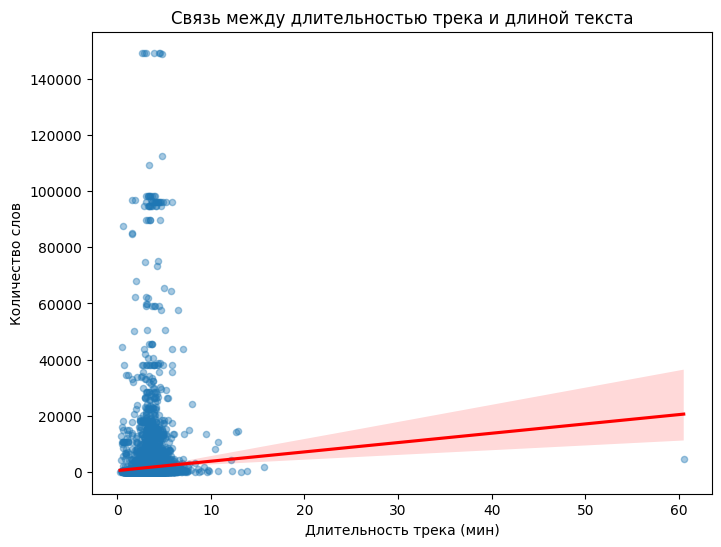

In [33]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=df,
    x="duration_min",
    y="lyrics_length_words",
    scatter_kws={"alpha": 0.4, "s": 20},
    line_kws={"color": "red"}
)

plt.title("Связь между длительностью трека и длиной текста")
plt.xlabel("Длительность трека (мин)")
plt.ylabel("Количество слов")

plt.show()

In [34]:
df["duration_min"].describe()

,duration_min
count,11777.000000
mean,3.440594
std,0.987893
min,0.312533
25%,3.080133
50%,3.398233
75%,3.786283
max,60.505050


In [39]:
# смотрим, какие аудио самые длинные

top5 = df.sort_values("duration_ms", ascending=False).head(5).copy()

top5[["track_name", "artist_name", "duration_ms", "duration_min"]]

,track_name,artist_name,duration_ms,duration_min
4329,Thought Of You (Sleep Mix),John Park,3630303,60.505050
676,AUTOMATIC REMIX,BIBI,938893,15.648217
4559,Baby I Miss You (Live),KAI,830345,13.839083
8881,Ending,PLAVE,792937,13.215617
9342,OPENING MESSAGE FROM RIIZE,RIIZE,775566,12.926100


In [40]:
top5_min = df.sort_values("duration_ms", ascending=True).head(5).copy()

top5_min[["track_name", "artist_name", "duration_ms", "duration_min"]]

,track_name,artist_name,duration_ms,duration_min
3677,Message from JENNIE,JENNIE,18752,0.312533
4427,With Latto,Jung Kook,23056,0.384267
8099,Message from NewJeans (EN),NewJeans,25592,0.426533
4434,About Seven,Jung Kook,27560,0.459333
898,Comment - Ma City,BTS,29229,0.487150


Средняя длительность трека составляет 3,44 минуты, медиана — 3,40 минуты, что говорит о том, что большинство композиций имеют схожую продолжительность. Половина треков находится в диапазоне примерно от 3,08 до 3,79 минуты, что соответствует обычной длительности поп-песен. Максимальная длительность превышает 60 минут, минимальная — одна треть минуты. Наиболее длинные аудио составляют ремиксы (в том числе самый длинный трек — ремикс для сна), записи с концертов. Наиболее короткие — сообщения от поп-айдолов, их комментарии.

/tmp/ipykernel_5214/2881056626.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["solo", "group"])
/tmp/ipykernel_5214/2881056626.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["boys", "girls", "mixed"])


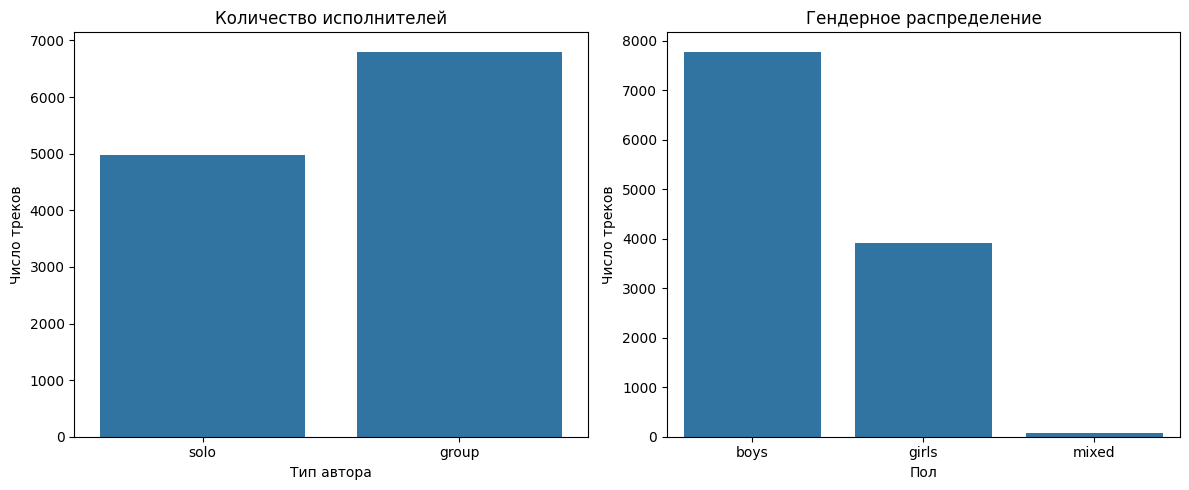

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# is_group
sns.countplot(
    data=df,
    x="is_group",
    ax=axes[0]
)

axes[0].set_xticklabels(["solo", "group"])
axes[0].set_title("Количество исполнителей")
axes[0].set_xlabel("Тип автора")
axes[0].set_ylabel("Число треков")

# gender_type
sns.countplot(
    data=df,
    x="gender_type",
    ax=axes[1]
)
axes[1].set_xticklabels(["boys", "girls", "mixed"])
axes[1].set_title("Гендерное распределение")
axes[1].set_xlabel("Пол")
axes[1].set_ylabel("Число треков")

plt.tight_layout()
plt.show()

По признаку is_group видно, что в датасете преобладают группы: 6804 группы против 4973 сольных исполнителей. Мы наблюдаем небольшое смещение выборки в сторону групповых k-pop проектов, что может повлиять на итоговую модель.

Из второго графика видно, что большинство наблюдений — это boys-группы (7780 записей), затем girls-группы (3913), и совсем небольшую долю составляют mixed-группы (84). Это показывает сильный дисбаланс классов, особенно для mixed-категории, которая представлена крайне слабо и может быть статистически нестабильной в анализе и моделировании.

Тем не менее, графики отражают естественное распределение внутри к-поп индустрии.

## 2. Смотрим на анализируемые тексты

In [54]:
import re

In [57]:
# определяем язык текста через регулярные выражения

def detect_language(text):

    english = len(re.findall(r"[A-Za-z]", text))
    korean = len(re.findall(r"[\uac00-\ud7af]", text))

    if english > korean and english > 0:
        return "English"

    elif korean > english and korean > 0:
        return "Korean"

    else:
        return "Other"

In [59]:
df["language"] = df["lyrics"].apply(detect_language)

In [60]:
# переводим в проценты содержания

language_percent = (
    df["language"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(language_percent)

language
English    67.5
Korean     31.8
Other       0.7
Name: proportion, dtype: float64


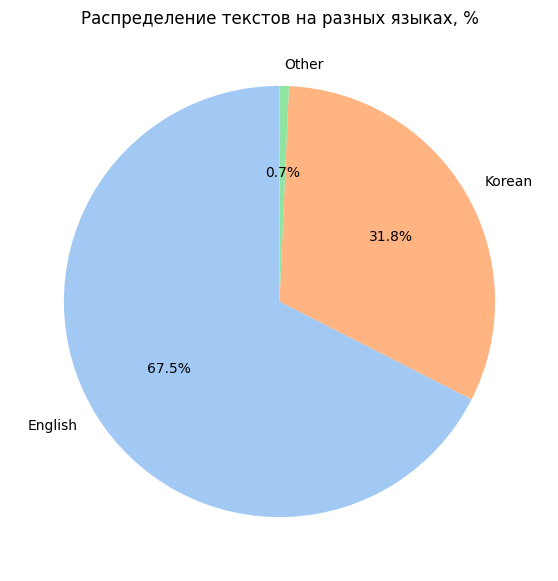

In [62]:
plt.figure(figsize=(7,7))

plt.pie(
    language_percent,
    labels=language_percent.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("pastel")
)

plt.title("Распределение текстов на разных языках, %")

plt.show()

Посмотрим на содержание текстов

In [63]:
!pip install wordcloud nltk

In [64]:
import nltk
nltk.download("punkt")
nltk.download('punkt_tab')
nltk.download("wordnet")
nltk.download("stopwords")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [65]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))

In [66]:
english_text = " ".join(df.loc[df["language"]=="English","lyrics"].dropna())

In [73]:
tokens = word_tokenize(english_text.lower())

tokens = [
    lemmatizer.lemmatize(word)
    for word in tokens
    if word.isalpha()]

# проверяем на стоп-слова
tokens = [
    word
    for word in tokens
    if word not in stop_words]

clean_text = " ".join(tokens)

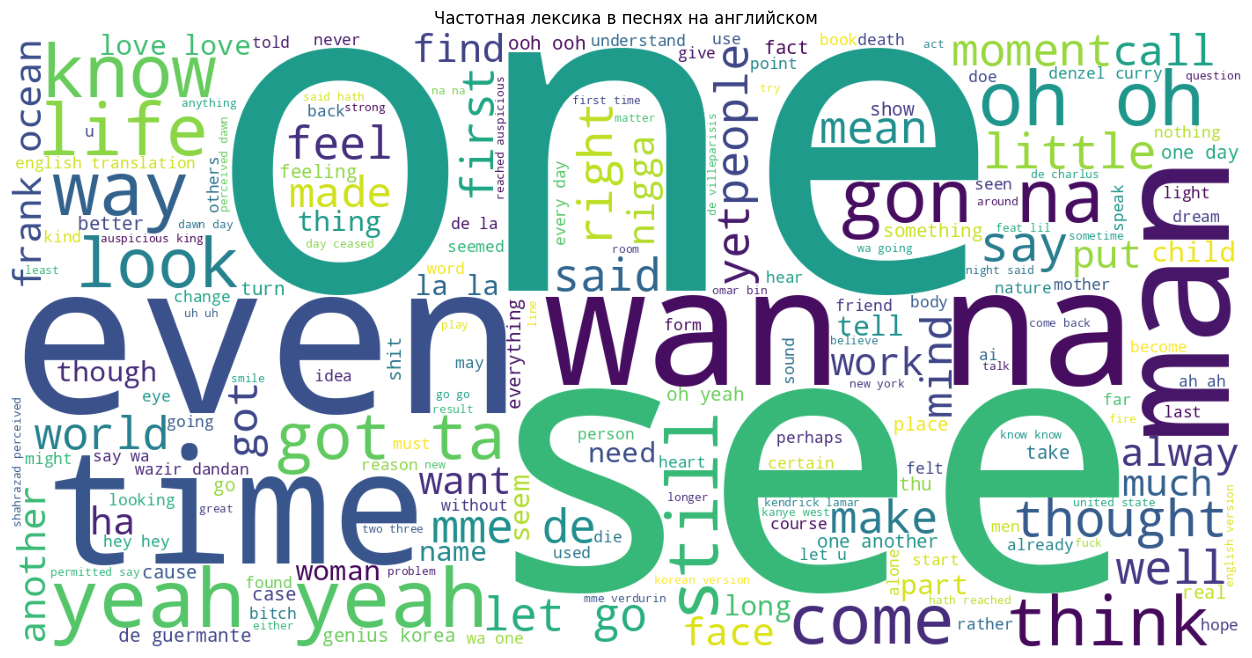

In [76]:
# строим облако слов

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white",
).generate(clean_text)

plt.figure(figsize=(16,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Частотная лексика в песнях на английском")
plt.show()

## 3. Корреляционная матрица

In [78]:
numeric = df.select_dtypes(include=np.number).columns

<Axes: >

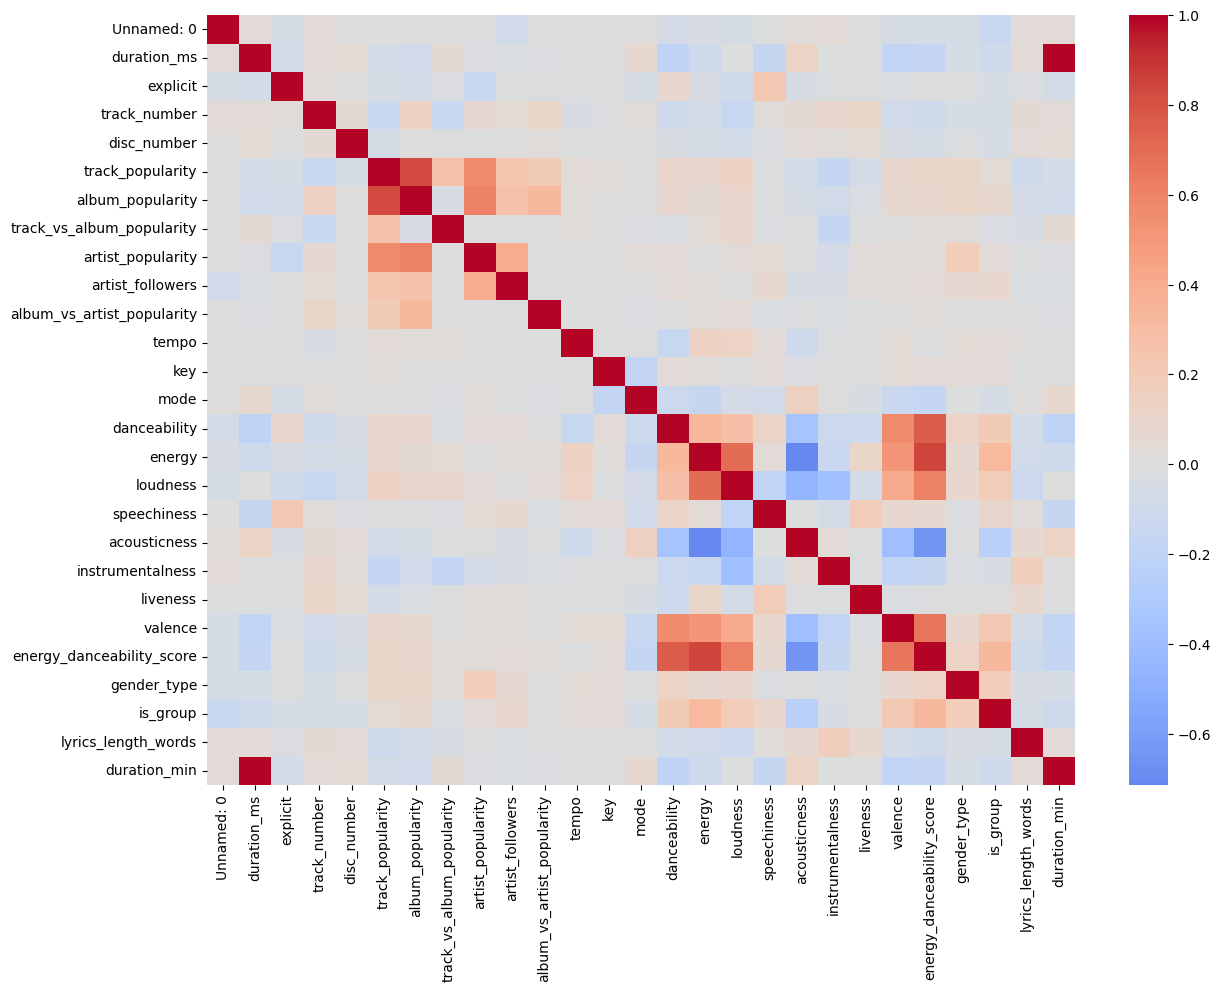

In [79]:
corr = df[numeric].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr,
            cmap="coolwarm",
            center=0)

Смотрим корреляцию только с целевой переменной:

In [80]:
corr["track_popularity"].sort_values(ascending=False)

,track_popularity
track_popularity,1.000000
album_popularity,0.828744
artist_popularity,0.560428
track_vs_album_popularity,0.267847
artist_followers,0.242478
album_vs_artist_popularity,0.198212
loudness,0.143772
energy_danceability_score,0.106542
gender_type,0.104501
danceability,0.101581


Наибольший вклад в популярность трека вносят метрики популярности исполнителя и альбома, в то время как аудиофичи показывают слабую линейную связь, что указывает на сложную природу популярности.